# Tibetan Research SDK Starter

This notebook demonstrates modular testing in a researcher workflow: segmentation, embeddings, and pairwise top-k retrieval.

In [1]:
import sys
from pathlib import Path

def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "tibetan_pipeline").exists() and (candidate / "requirements.txt").exists():
            return candidate
    raise RuntimeError("Could not find project root containing tibetan_pipeline/ and requirements.txt")

project_root = find_project_root(Path.cwd())
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from tibetan_pipeline import TibetanResearchSDK
print(f"project_root={project_root}")


/opt/homebrew/Caskroom/miniconda/base/envs/embedding-tibetan-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


project_root=/Users/ten-jampa/Documents/personal_projects/embedding-model-for-tibetan-pairwise


In [2]:
sdk = TibetanResearchSDK(
    engine="botok_ours",
    source_format="unicode",
    model_id="buddhist-nlp/gemma-2-mitra-e",
    device="cpu",
    batch_size=1,
)

In [3]:
text_a = "བོད་ཀྱི་རི་ཁྲོད་ན་རླུང་གི་སྒྲ་དང་ཆུ་ཡི་སྒྲ་གཉིས་མཉམ་དུ་ཐོས་པ་ཡོད། ཉི་མ་ཤར་བའི་དུས་སུ་རི་རྩེ་དང་གངས་རི་དག་ལ་གསལ་པོར་འོད་འཕྲོ་བ་མཐོང་ཐུབ། མི་ཚོས་ས་ཆ་དེར་ཞི་བའི་སེམས་དང་དགའ་བ་ཆེན་པོ་མྱོང་གི་ཡོད། རང་བཞིན་གྱི་མཛེས་སྡུག་དེས་མི་ཚོའི་སེམས་ལ་བདེ་བ་སྐྱེད་པ་ཡིན།"
text_b = "སློབ་གྲྭའི་ནང་དུ་སློབ་མ་ཚོས་ཉིན་རེར་ཤེས་ཡོན་གསར་པ་མང་པོ་སློབ་ཀྱི་ཡོད། དགེ་རྒན་ཚོས་སློབ་མ་རྣམས་ལ་དྲི་བ་འདྲི་བ་དང་གསལ་བཤད་བྱས་ཏེ་རིག་པ་འཕེལ་བར་བྱེད། སློབ་མ་ཚོས་མཉམ་དུ་ལས་ཀ་བྱས་པ་དང་གྲོས་བསྡུར་བྱས་པས་སློབ་སྦྱོང་ལ་དགའ་བ་སྐྱེས། དེ་ལས་སློབ་མ་ཚོའི་མི་ཚེའི་མདུན་ལམ་ཡང་དེ་བས་གསལ་བོ་འགྱོ་བ་ཡིན།"
seg_a = sdk.segment_text(text_a)
seg_a.to_dataframe().head()

,segment_index,start,end,segment_text
0,0,0,66,བོད་ཀྱི་རི་ཁྲོད་ན་རླུང་གི་སྒྲ་དང་ཆུ་ཡི་སྒྲ་གཉི...
1,1,66,136,ཉི་མ་ཤར་བའི་དུས་སུ་རི་རྩེ་དང་གངས་རི་དག་ལ་གསལ་པ...
2,2,136,192,མི་ཚོས་ས་ཆ་དེར་ཞི་བའི་སེམས་དང་དགའ་བ་ཆེན་པོ་མྱོ...
3,3,192,251,རང་བཞིན་གྱི་མཛེས་སྡུག་དེས་མི་ཚོའི་སེམས་ལ་བདེ་བ...


In [5]:
for segment in seg_a.segments:
    print(segment)


བོད་ཀྱི་རི་ཁྲོད་ན་རླུང་གི་སྒྲ་དང་ཆུ་ཡི་སྒྲ་གཉིས་མཉམ་དུ་ཐོས་པ་ཡོད།
ཉི་མ་ཤར་བའི་དུས་སུ་རི་རྩེ་དང་གངས་རི་དག་ལ་གསལ་པོར་འོད་འཕྲོ་བ་མཐོང་ཐུབ།
མི་ཚོས་ས་ཆ་དེར་ཞི་བའི་སེམས་དང་དགའ་བ་ཆེན་པོ་མྱོང་གི་ཡོད།
རང་བཞིན་གྱི་མཛེས་སྡུག་དེས་མི་ཚོའི་སེམས་ལ་བདེ་བ་སྐྱེད་པ་ཡིན།


In [6]:
seg_b = sdk.segment_text(text_b)    
seg_b.to_dataframe().head()

,segment_index,start,end,segment_text
0,0,0,70,སློབ་གྲྭའི་ནང་དུ་སློབ་མ་ཚོས་ཉིན་རེར་ཤེས་ཡོན་གས...
1,1,70,147,དགེ་རྒན་ཚོས་སློབ་མ་རྣམས་ལ་དྲི་བ་འདྲི་བ་དང་གསལ་...
2,2,147,223,སློབ་མ་ཚོས་མཉམ་དུ་ལས་ཀ་བྱས་པ་དང་གྲོས་བསྡུར་བྱས...
3,3,223,284,དེ་ལས་སློབ་མ་ཚོའི་མི་ཚེའི་མདུན་ལམ་ཡང་དེ་བས་གསལ...


In [7]:
for segment in seg_b.segments:
    print(segment)


སློབ་གྲྭའི་ནང་དུ་སློབ་མ་ཚོས་ཉིན་རེར་ཤེས་ཡོན་གསར་པ་མང་པོ་སློབ་ཀྱི་ཡོད།
དགེ་རྒན་ཚོས་སློབ་མ་རྣམས་ལ་དྲི་བ་འདྲི་བ་དང་གསལ་བཤད་བྱས་ཏེ་རིག་པ་འཕེལ་བར་བྱེད།
སློབ་མ་ཚོས་མཉམ་དུ་ལས་ཀ་བྱས་པ་དང་གྲོས་བསྡུར་བྱས་པས་སློབ་སྦྱོང་ལ་དགའ་བ་སྐྱེས།
དེ་ལས་སློབ་མ་ཚོའི་མི་ཚེའི་མདུན་ལམ་ཡང་དེ་བས་གསལ་བོ་འགྱོ་བ་ཡིན།


In [8]:
embedding_view = sdk.embed_sentences(seg_a.segments)
embedding_view.to_dataframe().head()


The following generation flags are not valid and may be ignored: ['cache_implementation']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Loading weights: 100%|██████████| 464/464 [00:00<00:00, 1964.90it/s, Materializing param=model.norm.weight]                                


,sentence_index,sentence_text,vector_norm
0,0,བོད་ཀྱི་རི་ཁྲོད་ན་རླུང་གི་སྒྲ་དང་ཆུ་ཡི་སྒྲ་གཉི...,1.0
1,1,ཉི་མ་ཤར་བའི་དུས་སུ་རི་རྩེ་དང་གངས་རི་དག་ལ་གསལ་པ...,1.0
2,2,མི་ཚོས་ས་ཆ་དེར་ཞི་བའི་སེམས་དང་དགའ་བ་ཆེན་པོ་མྱོ...,1.0
3,3,རང་བཞིན་གྱི་མཛེས་སྡུག་དེས་མི་ཚོའི་སེམས་ལ་བདེ་བ...,1.0


In [9]:
embedding_view_a = embedding_view

In [10]:
embedding_view_b = sdk.embed_sentences(seg_b.segments)
embedding_view_b.to_dataframe().head()

Loading weights: 100%|██████████| 464/464 [00:00<00:00, 1846.18it/s, Materializing param=model.norm.weight]                                


,sentence_index,sentence_text,vector_norm
0,0,སློབ་གྲྭའི་ནང་དུ་སློབ་མ་ཚོས་ཉིན་རེར་ཤེས་ཡོན་གས...,1.0
1,1,དགེ་རྒན་ཚོས་སློབ་མ་རྣམས་ལ་དྲི་བ་འདྲི་བ་དང་གསལ་...,1.0
2,2,སློབ་མ་ཚོས་མཉམ་དུ་ལས་ཀ་བྱས་པ་དང་གྲོས་བསྡུར་བྱས...,1.0
3,3,དེ་ལས་སློབ་མ་ཚོའི་མི་ཚེའི་མདུན་ལམ་ཡང་དེ་བས་གསལ...,1.0


In [11]:
from tibetan_pipeline.sdk import cosine_similarity_matrix, global_top_k_matches, PairwiseView

In [12]:
## custom code to do the pairwise calculation if the embeddings have already been calculated
# The error occurs because global_top_k_matches() does not accept 'top_k' as a keyword argument.
# Let's inspect its signature and call it with correct arguments. 
# If the correct argument is positional, pass it as such, not as a keyword.

# For most cosine similarity ranking utilities, the order may be:
# global_top_k_matches(matrix, sentences_a, sentences_b, k)
# Adjust accordingly (remove top_k=).

def _pairwise_from_embeddings(self, other, top_k: int = 5) -> PairwiseView:
    matrix = cosine_similarity_matrix(self.embeddings, other.embeddings)
    # Correction: pass top_k as a positional argument, not keyword, if expected so
    matches = global_top_k_matches(matrix, self.sentences, other.sentences, top_k)
    return PairwiseView(
        model_id=self.model_id,
        device=self.device,
        segments_a=self.sentences,
        segments_b=other.sentences,
        similarity_matrix=matrix,
        matches=matches,
    )

pairwise_view = _pairwise_from_embeddings(embedding_view_a, embedding_view_b)

pairwise_view

PairwiseView(model_id='buddhist-nlp/gemma-2-mitra-e', device='cpu', segments_a=['བོད་ཀྱི་རི་ཁྲོད་ན་རླུང་གི་སྒྲ་དང་ཆུ་ཡི་སྒྲ་གཉིས་མཉམ་དུ་ཐོས་པ་ཡོད།', 'ཉི་མ་ཤར་བའི་དུས་སུ་རི་རྩེ་དང་གངས་རི་དག་ལ་གསལ་པོར་འོད་འཕྲོ་བ་མཐོང་ཐུབ།', 'མི་ཚོས་ས་ཆ་དེར་ཞི་བའི་སེམས་དང་དགའ་བ་ཆེན་པོ་མྱོང་གི་ཡོད།', 'རང་བཞིན་གྱི་མཛེས་སྡུག་དེས་མི་ཚོའི་སེམས་ལ་བདེ་བ་སྐྱེད་པ་ཡིན།'], segments_b=['སློབ་གྲྭའི་ནང་དུ་སློབ་མ་ཚོས་ཉིན་རེར་ཤེས་ཡོན་གསར་པ་མང་པོ་སློབ་ཀྱི་ཡོད།', 'དགེ་རྒན་ཚོས་སློབ་མ་རྣམས་ལ་དྲི་བ་འདྲི་བ་དང་གསལ་བཤད་བྱས་ཏེ་རིག་པ་འཕེལ་བར་བྱེད།', 'སློབ་མ་ཚོས་མཉམ་དུ་ལས་ཀ་བྱས་པ་དང་གྲོས་བསྡུར་བྱས་པས་སློབ་སྦྱོང་ལ་དགའ་བ་སྐྱེས།', 'དེ་ལས་སློབ་མ་ཚོའི་མི་ཚེའི་མདུན་ལམ་ཡང་དེ་བས་གསལ་བོ་འགྱོ་བ་ཡིན།'], similarity_matrix=array([[0.3918082 , 0.30438712, 0.36354983, 0.33653054],
       [0.4211165 , 0.36429438, 0.37308785, 0.47688946],
       [0.43946594, 0.35884088, 0.47102752, 0.4152441 ],
       [0.37153065, 0.37198415, 0.42630604, 0.42282867]], dtype=float32), matches=[PairMatch(rank=1, score=0.4768894612789154, i=1, j=3, sentence_a='ཉི་མ་ཤར

In [13]:
pairwise_view.topk_dataframe()

,rank,score,i,j,sentence_a,sentence_b
0,1,0.476889,1,3,ཉི་མ་ཤར་བའི་དུས་སུ་རི་རྩེ་དང་གངས་རི་དག་ལ་གསལ་པ...,དེ་ལས་སློབ་མ་ཚོའི་མི་ཚེའི་མདུན་ལམ་ཡང་དེ་བས་གསལ...
1,2,0.471028,2,2,མི་ཚོས་ས་ཆ་དེར་ཞི་བའི་སེམས་དང་དགའ་བ་ཆེན་པོ་མྱོ...,སློབ་མ་ཚོས་མཉམ་དུ་ལས་ཀ་བྱས་པ་དང་གྲོས་བསྡུར་བྱས...
2,3,0.439466,2,0,མི་ཚོས་ས་ཆ་དེར་ཞི་བའི་སེམས་དང་དགའ་བ་ཆེན་པོ་མྱོ...,སློབ་གྲྭའི་ནང་དུ་སློབ་མ་ཚོས་ཉིན་རེར་ཤེས་ཡོན་གས...
3,4,0.426306,3,2,རང་བཞིན་གྱི་མཛེས་སྡུག་དེས་མི་ཚོའི་སེམས་ལ་བདེ་བ...,སློབ་མ་ཚོས་མཉམ་དུ་ལས་ཀ་བྱས་པ་དང་གྲོས་བསྡུར་བྱས...
4,5,0.422829,3,3,རང་བཞིན་གྱི་མཛེས་སྡུག་དེས་མི་ཚོའི་སེམས་ལ་བདེ་བ...,དེ་ལས་སློབ་མ་ཚོའི་མི་ཚེའི་མདུན་ལམ་ཡང་དེ་བས་གསལ...


In [14]:
for row in pairwise_view.topk_dataframe().itertuples():
    print(f'{row.sentence_a} -> {row.sentence_b} : {row.score}')
    

ཉི་མ་ཤར་བའི་དུས་སུ་རི་རྩེ་དང་གངས་རི་དག་ལ་གསལ་པོར་འོད་འཕྲོ་བ་མཐོང་ཐུབ། -> དེ་ལས་སློབ་མ་ཚོའི་མི་ཚེའི་མདུན་ལམ་ཡང་དེ་བས་གསལ་བོ་འགྱོ་བ་ཡིན། : 0.4768894612789154
མི་ཚོས་ས་ཆ་དེར་ཞི་བའི་སེམས་དང་དགའ་བ་ཆེན་པོ་མྱོང་གི་ཡོད། -> སློབ་མ་ཚོས་མཉམ་དུ་ལས་ཀ་བྱས་པ་དང་གྲོས་བསྡུར་བྱས་པས་སློབ་སྦྱོང་ལ་དགའ་བ་སྐྱེས། : 0.47102752327919006
མི་ཚོས་ས་ཆ་དེར་ཞི་བའི་སེམས་དང་དགའ་བ་ཆེན་པོ་མྱོང་གི་ཡོད། -> སློབ་གྲྭའི་ནང་དུ་སློབ་མ་ཚོས་ཉིན་རེར་ཤེས་ཡོན་གསར་པ་མང་པོ་སློབ་ཀྱི་ཡོད། : 0.4394659399986267
རང་བཞིན་གྱི་མཛེས་སྡུག་དེས་མི་ཚོའི་སེམས་ལ་བདེ་བ་སྐྱེད་པ་ཡིན། -> སློབ་མ་ཚོས་མཉམ་དུ་ལས་ཀ་བྱས་པ་དང་གྲོས་བསྡུར་བྱས་པས་སློབ་སྦྱོང་ལ་དགའ་བ་སྐྱེས། : 0.4263060390949249
རང་བཞིན་གྱི་མཛེས་སྡུག་དེས་མི་ཚོའི་སེམས་ལ་བདེ་བ་སྐྱེད་པ་ཡིན། -> དེ་ལས་སློབ་མ་ཚོའི་མི་ཚེའི་མདུན་ལམ་ཡང་དེ་བས་གསལ་བོ་འགྱོ་བ་ཡིན། : 0.42282867431640625


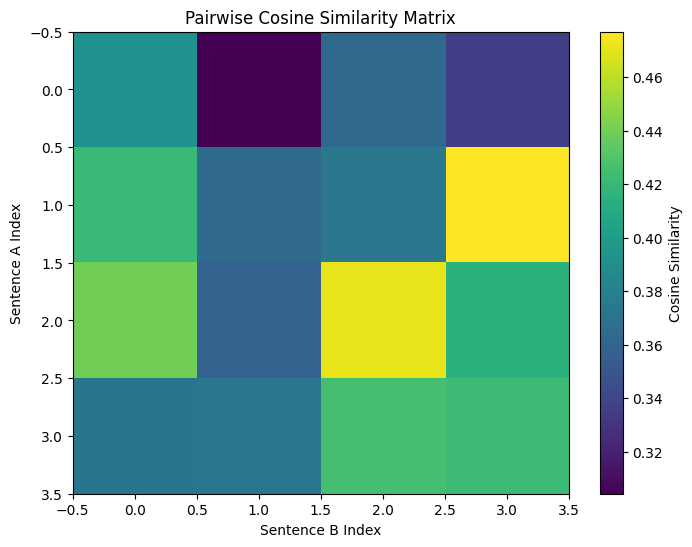

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Plot the similarity (heat) matrix
plt.figure(figsize=(8, 6))
plt.imshow(pairwise_view.similarity_matrix, cmap="viridis", aspect="auto")
plt.colorbar(label="Cosine Similarity")
plt.title("Pairwise Cosine Similarity Matrix")
plt.xlabel("Sentence B Index")
plt.ylabel("Sentence A Index")
plt.show()

In [ ]:
pairwise_view = sdk.pairwise(text_a, text_b, top_k=5)
pairwise_view.topk_dataframe()

# Some more testing with two real text by Tsonkhapa

## ``Praise to Saraswati`` text sample

In [16]:
saraswati_praise_text = """
༄༅། །སྒྲ་དབྱངས་ལྷ་མོ་དབྱངས་ཅན་མ་ལ་བསྟོད་པ།
 
ཨོཾ་བདེ་ལེགས་སུ་གྱུར་ཅིག
 

ཆུ་འཛིན་དཀར་པོའི་གློག་ཕྲེང་དྲ་བ་ཅན། །
མཁའ་ཡི་མཛེས་བྱེད་འདྲ་བའི་ཡིད་འཕྲོག་མ། །
དྲི་ཟའི་ན་ཆུང་དབུས་ན་འཇོ་སྒེག་མཁན། །
རིང་ནས་བརྩེ་བའི་ལྷ་མོ་ད་ཚུར་བྱོན། །
 

པད་མའི་བཞིན་ལ་གཡོ་ལྡན་བུང་བའི་མིག །
མཐོན་མཐིང་རལ་པའི་རྩེ་ན་འོད་དཀར་ཅན། །
རོལ་སྒེག་གར་གྱིས་འགྱིང་བའི་དབྱངས་ཅན་མ། །
ད་དུང་བདག་ལ་ངག་གི་དངོས་གྲུབ་སྩོལ། །
 

རོལ་རྩེད་གར་གྱི་ཉམས་ལྡན་རི་དྭགས་མིག །
མིག་གིས་བལྟ་བས་མི་ངོམ་ཡིད་འཕྲོག་མ། །
མ་ལྟར་བརྩེ་བ་ཁྱེད་ཀྱིས་བདག་གི་ངག །
ངག་དབང་ལྷ་མོ་ཉིད་དང་མཚུངས་པར་མཛོད། །
 

སྟོན་ཟླ་རྒྱས་པའི་དཔལ་ལས་ལྷག་པར་མཛེས། །
ཚངས་དབྱངས་སྙན་པའི་གདངས་ཀྱང་ཟིལ་གྱིས་གནོན། །
ཟབ་ཡངས་རྒྱ་མཚོའི་འཇིང་ལྟར་དཔག་དཀའ་བ། །
དབྱངས་ཅན་ལྷ་མོའི་སྐུ་གསུང་ཐུགས་ལ་འདུད། །
"""

In [17]:
saraswati_praise_text_segmented = sdk.segment_text(saraswati_praise_text)
for segment in saraswati_praise_text_segmented.segments:
    print(segment)


༄༅། །སྒྲ་དབྱངས་ལྷ་མོ་དབྱངས་ཅན་མ་ལ་བསྟོད་པ།
ཨོཾ་བདེ་ལེགས་སུ་གྱུར་ཅིག ཆུ་འཛིན་དཀར་པོའི་གློག་ཕྲེང་དྲ་བ་ཅན། །
མཁའ་ཡི་མཛེས་བྱེད་འདྲ་བའི་ཡིད་འཕྲོག་མ། །
དྲི་ཟའི་ན་ཆུང་དབུས་ན་འཇོ་སྒེག་མཁན། །
རིང་ནས་བརྩེ་བའི་ལྷ་མོ་ད་ཚུར་བྱོན། །
པད་མའི་བཞིན་ལ་གཡོ་ལྡན་བུང་བའི་མིག །
མཐོན་མཐིང་རལ་པའི་རྩེ་ན་འོད་དཀར་ཅན། །
རོལ་སྒེག་གར་གྱིས་འགྱིང་བའི་དབྱངས་ཅན་མ། །
ད་དུང་བདག་ལ་ངག་གི་དངོས་གྲུབ་སྩོལ། །
རོལ་རྩེད་གར་གྱི་ཉམས་ལྡན་རི་དྭགས་མིག །
མིག་གིས་བལྟ་བས་མི་ངོམ་ཡིད་འཕྲོག་མ། །
མ་ལྟར་བརྩེ་བ་ཁྱེད་ཀྱིས་བདག་གི་ངག །
ངག་དབང་ལྷ་མོ་ཉིད་དང་མཚུངས་པར་མཛོད། །
སྟོན་ཟླ་རྒྱས་པའི་དཔལ་ལས་ལྷག་པར་མཛེས། །
ཚངས་དབྱངས་སྙན་པའི་གདངས་ཀྱང་ཟིལ་གྱིས་གནོན། །
ཟབ་ཡངས་རྒྱ་མཚོའི་འཇིང་ལྟར་དཔག་དཀའ་བ། །
དབྱངས་ཅན་ལྷ་མོའི་སྐུ་གསུང་ཐུགས་ལ་འདུད། །


## ``Foundation of all good qualities`` text by Tsonkhapa

In [18]:
foundation_of_all_good_qualities_text = """
༄༅། །ཡོན་ཏན་གཞིར་གྱུར་མ་བཞུགས་སོ། །
 

ཡོན་ཏན་ཀུན་གྱི་གཞིར་གྱུར་དྲིན་ཅན་རྗེ། །
ཚུལ་བཞིན་བསྟེན་པ་ལམ་གྱི་རྩ་བ་རུ། །
ལེགས་པར་མཐོང་ནས་འབད་པ་དུ་མ་ཡིས། །
གུས་པ་ཆེན་པོས་བསྟེན་པར་བྱིན་གྱིས་རློབས། །
 

ལན་ཅིག་རྙེད་པའི་དལ་བའི་རྟེན་བཟང་འདི། །
ཤིན་ཏུ་རྙེད་དཀའ་དོན་ཆེ་ཤེས་གྱུར་ནས། །
ཉིན་མཚན་ཀུན་ཏུ་སྙིང་པོ་ལེན་པའི་བློ། །
རྒྱུན་ཆད་མེད་པར་སྐྱེ་བར་བྱིན་གྱིས་རློབས། །
 

ལུས་སྲོག་གཡོ་བ་ཆུ་ཡི་ཆུ་བུར་བཞིན། །
མྱུར་དུ་འཇིག་པའི་འཆི་བ་དྲན་པ་དང༌། །
ཤི་བའི་རྗེས་སུ་ལུས་དང་གྲིབ་མ་བཞིན། །
དཀར་ནག་ལས་འབྲས་ཕྱི་བཞིན་འབྲང་བ་ལ། །
 

ངེས་པ་བརྟན་པོ་རྙེད་ནས་ཉེས་པའི་ཚོགས། །
ཕྲ་ཞིང་ཕྲ་བ་རྣམས་ཀྱང་སྤོང་བ་དང༌། །
དགེ་ཚོགས་མཐའ་དག་སྒྲུབ་པར་བྱེད་པ་ལ། །
རྟག་ཏུ་བག་དང་ལྡན་པར་བྱིན་གྱིས་རློབས། །
 

སྤྱད་པས་མི་ངོམས་སྡུག་བསྔལ་ཀུན་གྱི་སྒོ། །
ཡིད་བརྟན་མི་རུང་སྲིད་པའི་ཕུན་ཚོགས་ཀྱི། །
ཉེས་དམིགས་རིག་ནས་ཐར་བའི་བདེ་བ་ལ། །
དོན་གཉེར་ཆེན་པོ་སྐྱེ་བར་བྱིན་གྱིས་རློབས། །
 

རྣམ་དག་བསམ་པ་དེ་ཡིས་དྲངས་པ་ཡི། །
དྲན་དང་ཤེས་བཞིན་བག་ཡོད་ཆེན་པོ་ཡིས། །
བསྟན་པའི་རྩ་བ་སོ་སོར་ཐར་བ་ལ། །
སྒྲུབ་པ་སྙིང་པོར་བྱེད་པར་བྱིན་གྱིས་རློབས། །
 

རང་ཉིད་སྲིད་མཚོར་ལྷུང་བ་ཇི་བཞིན་དུ། །
མར་གྱུར་འགྲོ་བ་ཀུན་ཀྱང་དེ་འདྲ་བར། །
མཐོང་ནས་འགྲོ་བ་སྒྲོལ་བའི་ཁུར་འཁྱེར་བའི། །
བྱང་ཆུབ་སེམས་མཆོག་འབྱོངས་པར་བྱིན་གྱིས་རློབས། །
 

སེམས་ཙམ་བསྐྱེད་ཀྱང་ཚུལ་ཁྲིམས་རྣམ་གསུམ་ལ། །
གོམས་པ་མེད་ན་བྱང་ཆུབ་མི་འགྲུབ་པར། །
ལེགས་པར་མཐོང་ནས་རྒྱལ་སྲས་སྡོམ་པ་ལ། །
བརྩོན་པ་དྲག་པོས་སློབ་པར་བྱིན་གྱིས་རློབས། །
 

ལོག་པའི་ཡུལ་ལ་གཡེངས་པ་ཞི་བྱེད་ཅིང༌། །
ཡང་དག་དོན་ལ་ཚུལ་བཞིན་དཔྱོད་པ་ཡིས། །
ཞི་གནས་ལྷག་མཐོང་ཟུང་དུ་འབྲེལ་བའི་ལམ། །
མྱུར་དུ་རྒྱུད་ལ་སྐྱེ་བར་བྱིན་གྱིས་རློབས། །
 

ཐུན་མོང་ལམ་སྦྱང་སྣོད་དུ་གྱུར་པ་ན། །
ཐེག་པ་ཀུན་གྱི་མཆོག་གྱུར་རྡོ་རྗེ་ཐེག།
སྐལ་བཟང་སྐྱེ་བོའི་འཇུག་ངོགས་དམ་པ་དེར། །
བདེ་བླག་ཉིད་དུ་འཇུག་པར་བྱིན་གྱིས་རློབས། །
 

དེ་ཚེ་དངོས་གྲུབ་རྣམ་གཉིས་སྒྲུབ་པའི་གཞི། །
རྣམ་དག་དམ་ཚིག་སྡོམ་པར་གསུངས་པ་ལ། །
བཅོས་མ་མིན་པའི་ངེས་པ་རྙེད་གྱུར་ནས། །
སྲོག་དང་བསྡོས་ཏེ་སྲུང་བར་བྱིན་གྱིས་རློབས། །
 

དེ་ནས་རྒྱུད་སྡེ་སྙིང་པོ་རིམ་གཉིས་ཀྱི། །
གནད་རྣམས་ཇི་བཞིན་རྟོགས་ནས་བརྩོན་པ་ཡིས། །
ཐུན་བཞིའི་རྣལ་འབྱོར་སྤྱོད་ལས་མི་གཡེལ་བར། །
དམ་པའི་གསུང་བཞིན་སྒྲུབ་པར་བྱིན་གྱིས་རློབས། །
 

དེ་ལྟར་ལམ་བཟང་སྟོན་པའི་བཤེས་གཉེན་དང༌། །
ཚུལ་བཞིན་སྒྲུབ་པའི་གྲོགས་རྣམས་ཞབས་བརྟན་ཅིང༌། །
ཕྱི་དང་ནང་གི་བར་དུ་གཅོད་པའི་ཚོགས། །
ཉེ་བར་ཞི་བར་བྱིན་གྱིས་བརླབ་ཏུ་གསོལ། །
 

སྐྱེ་བ་ཀུན་ཏུ་ཡང་དག་བླ་མ་དང་། །
འབྲལ་མེད་ཆོས་ཀྱི་དཔལ་ལ་ལོངས་སྤྱོད་ཅིང་། །
ས་དང་ལམ་གྱི་ཡོན་ཏན་རབ་རྫོགས་ནས། །
རྡོ་རྗེ་འཆང་གི་གོ་འཕང་མྱུར་ཐོབ་ཤོག །
 

ཅེས་པ་འདི་ནི་རྗེ་ཙོང་ཁ་པ་བློ་བཟང་གྲགས་པས་མཛད་པའོ། །
"""

In [19]:
foundation_of_all_good_qualities_text_segments = sdk.segment_text(
    foundation_of_all_good_qualities_text
)
foundation_of_all_good_qualities_text_segments.to_dataframe().head()

,segment_index,start,end,segment_text
0,0,0,36,༄༅། །ཡོན་ཏན་གཞིར་གྱུར་མ་བཞུགས་སོ། །
1,1,36,76,ཡོན་ཏན་ཀུན་གྱི་གཞིར་གྱུར་དྲིན་ཅན་རྗེ། །
2,2,76,111,ཚུལ་བཞིན་བསྟེན་པ་ལམ་གྱི་རྩ་བ་རུ། །
3,3,111,145,ལེགས་པར་མཐོང་ནས་འབད་པ་དུ་མ་ཡིས། །
4,4,145,187,གུས་པ་ཆེན་པོས་བསྟེན་པར་བྱིན་གྱིས་རློབས། །


In [20]:
for segment in foundation_of_all_good_qualities_text_segments.segments:
    print(segment)

༄༅། །ཡོན་ཏན་གཞིར་གྱུར་མ་བཞུགས་སོ། །
ཡོན་ཏན་ཀུན་གྱི་གཞིར་གྱུར་དྲིན་ཅན་རྗེ། །
ཚུལ་བཞིན་བསྟེན་པ་ལམ་གྱི་རྩ་བ་རུ། །
ལེགས་པར་མཐོང་ནས་འབད་པ་དུ་མ་ཡིས། །
གུས་པ་ཆེན་པོས་བསྟེན་པར་བྱིན་གྱིས་རློབས། །
ལན་ཅིག་རྙེད་པའི་དལ་བའི་རྟེན་བཟང་འདི། །
ཤིན་ཏུ་རྙེད་དཀའ་དོན་ཆེ་ཤེས་གྱུར་ནས། ། ཉིན་མཚན་ཀུན་ཏུ་སྙིང་པོ་ལེན་པའི་བློ། །
རྒྱུན་ཆད་མེད་པར་སྐྱེ་བར་བྱིན་གྱིས་རློབས། །
ལུས་སྲོག་གཡོ་བ་ཆུ་ཡི་ཆུ་བུར་བཞིན། ། མྱུར་དུ་འཇིག་པའི་འཆི་བ་དྲན་པ་དང༌། །
ཤི་བའི་རྗེས་སུ་ལུས་དང་གྲིབ་མ་བཞིན། ། དཀར་ནག་ལས་འབྲས་ཕྱི་བཞིན་འབྲང་བ་ལ། །
ངེས་པ་བརྟན་པོ་རྙེད་ནས་ཉེས་པའི་ཚོགས། །
ཕྲ་ཞིང་ཕྲ་བ་རྣམས་ཀྱང་སྤོང་བ་དང༌། །
དགེ་ཚོགས་མཐའ་དག་སྒྲུབ་པར་བྱེད་པ་ལ། །
རྟག་ཏུ་བག་དང་ལྡན་པར་བྱིན་གྱིས་རློབས། །
སྤྱད་པས་མི་ངོམས་སྡུག་བསྔལ་ཀུན་གྱི་སྒོ། །
ཡིད་བརྟན་མི་རུང་སྲིད་པའི་ཕུན་ཚོགས་ཀྱི། །
ཉེས་དམིགས་རིག་ནས་ཐར་བའི་བདེ་བ་ལ། །
དོན་གཉེར་ཆེན་པོ་སྐྱེ་བར་བྱིན་གྱིས་རློབས། །
རྣམ་དག་བསམ་པ་དེ་ཡིས་དྲངས་པ་ཡི། །
དྲན་དང་ཤེས་བཞིན་བག་ཡོད་ཆེན་པོ་ཡིས། །
བསྟན་པའི་རྩ་བ་སོ་སོར་ཐར་བ་ལ། །
སྒྲུབ་པ་སྙིང་པོར་བྱེད་པར་བྱིན་གྱིས་རློབས། །
རང་ཉིད་སྲིད་མཚོར་ལྷུང་བ་ཇི་བཞིན་དུ། །
མར་གྱུར་འགྲོ་བ་ཀུན